# Captain's Log: Environment Setup

Setting up the environment variables for buffer distances and initializing required libraries for geospatial analysis.

In [11]:
# Import required libraries
import geopandas as gpd
import pandas as pd
import folium
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
import urllib.parse
import requests
from io import BytesIO
import zipfile

# Load environment variables
load_dotenv()

# Get buffer distances from environment variables
BUFFER_HIGH = int(os.getenv('BUFFER_HIGH', 500))
BUFFER_MED = int(os.getenv('BUFFER_MED', 1000))
BUFFER_LOW = int(os.getenv('BUFFER_LOW', 2000))

print(f"Buffer distances loaded:")
print(f"HIGH: {BUFFER_HIGH}m")
print(f"MED: {BUFFER_MED}m")
print(f"LOW: {BUFFER_LOW}m")

Buffer distances loaded:
HIGH: 500m
MED: 1000m
LOW: 2000m


# Captain's Log: Loading River Data

Loading river polygon data from Water Resources Agency (WRA) and converting coordinate system to EPSG:3826 (Taiwan Datum 1997).

In [12]:
# Load river data from local file
import geopandas as gpd

try:
    # Load river data from local shapefile in data folder
    rivers_gdf = gpd.read_file("data/RIVREGLN.shp")
    
    # Convert CRS to EPSG:3826
    rivers_gdf = rivers_gdf.to_crs('EPSG:3826')
    
    print(f"River data loaded successfully!")
    print(f"Number of river features: {len(rivers_gdf)}")
    print(f"Original CRS: {rivers_gdf.crs}")
    print(f"Converted to EPSG:3826")
    print(f"\nColumn names: {list(rivers_gdf.columns)}")
    print(f"\nFirst few rows:")
    print(rivers_gdf.head())
    
except FileNotFoundError:
    print(f"Error: River shapefile not found at data/RIVREGLN.shp")
    print("Please check the file path and ensure the shapefile exists.")
    rivers_gdf = None
except Exception as e:
    print(f"Error loading river data: {e}")
    rivers_gdf = None

River data loaded successfully!
Number of river features: 230
Original CRS: EPSG:3826
Converted to EPSG:3826

Column names: ['BASIN_NAME', 'RV_NAME', 'RV_NO', 'MNG_NO', 'ORG_MNG', 'NOTE', 'geometry']

First few rows:
  BASIN_NAME    RV_NAME   RV_NO MNG_NO             ORG_MNG  NOTE  \
0  è±è®æºª  é³³ææºª  2420A0      1  ç¬¬ä¹æ²³å·åç½²  None   
1  é«å±æºª  èæ¿æºª  173010      1  ç¬¬ä¸æ²³å·åç½²  None   
2  é«å±æºª  èæ¿æºª  173010      1  ç¬¬ä¸æ²³å·åç½²  None   
3  ä¸­æ¸¯æºª  æ±æ²³æºª  134030      1  ç¬¬äºæ²³å·åç½²  None   
4  ä¸­æ¸¯æºª  åæ²³æºª  134020      1  ç¬¬äºæ²³å·åç½²  None   

                                            geometry  
0  POLYGON ((299852.733 2628852.645, 299792.399 2...  
1  POLYGON ((208253.801 2526751.566, 208238.585 2...  
2  POLYGON ((205866.964 2528133.425, 205835.479 2...  
3  POLYGON ((249993.372 2721139.947, 249997.57 27...  
4  POLYGON ((249943.623 2720998.174, 249942.042 2...  


# Captain's Log: Cleaning Shelter Data

Loading shelter data, filtering out abnormal coordinates (longitude: 119-122.5, latitude: 21-26.5), and converting to GeoDataFrame with EPSG:3826.

In [13]:
# Load shelter data from Fire Agency (data.gov.tw)
import pandas as pd
import geopandas as gpd

shelter_file = "data/避難收容處所點位檔案v9 (1).csv"

try:
    # Read CSV file using the exact method provided
    shelters_csv = pd.read_csv(shelter_file)  # 自行下載後放入 data/
    print(f"Original shelter data loaded: {len(shelters_csv)} records")
    
    # Display column names to understand the data structure
    print(f"\nColumn names: {list(shelters_csv.columns)}")
    
    # Data cleaning - filter out abnormal coordinates (Week 2 lesson)
    # Filter coordinates (longitude: 119-122.5, latitude: 21-26.5)
    filtered_csv = shelters_csv[
        (shelters_csv['經度'] >= 119) & 
        (shelters_csv['經度'] <= 122.5) & 
        (shelters_csv['緯度'] >= 21) & 
        (shelters_csv['緯度'] <= 26.5) &
        (shelters_csv['經度'] != 0) & 
        (shelters_csv['緯度'] != 0)  # Remove zero coordinates
    ]
    
    print(f"\nData cleaning results:")
    print(f"Original records: {len(shelters_csv)}")
    print(f"After filtering: {len(filtered_csv)}")
    print(f"Records removed: {len(shelters_csv) - len(filtered_csv)}")
    
    # Convert to GeoDataFrame using the exact method provided
    shelters_gdf = gpd.GeoDataFrame(
        filtered_csv,
        geometry=gpd.points_from_xy(filtered_csv['經度'], filtered_csv['緯度']),
        crs='EPSG:4326'
    )
    
    # Convert CRS to EPSG:3826
    shelters_gdf = shelters_gdf.to_crs('EPSG:3826')
    
    print(f"\nShelter data converted to GeoDataFrame with EPSG:3826")
    print(f"Final shelter count: {len(shelters_gdf)}")
    
except FileNotFoundError:
    print(f"Error: File {shelter_file} not found. Please check the file path.")
    shelters_gdf = None
except KeyError as e:
    print(f"Error: Missing expected columns {e}. Please check CSV structure.")
    shelters_gdf = None
except Exception as e:
    print(f"Error processing shelter data: {e}")
    shelters_gdf = None

Original shelter data loaded: 5973 records

Column names: ['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置']

Data cleaning results:
Original records: 5973
After filtering: 5907
Records removed: 66

Shelter data converted to GeoDataFrame with EPSG:3826
Final shelter count: 5907


# Captain's Log: Loading Township Boundaries

Loading township boundary data from TGOS API with URL encoding, and converting to EPSG:3826. Fallback to local file if API fails.

In [14]:
# Load township boundaries from National Land Surveying and Mapping Center
from urllib.parse import quote
import geopandas as gpd

# TGOS URL using the exact pattern provided
url = 'https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/' + quote('鄉(鎮、市、區)界線1140318.zip')

# Fallback local path
local_fallback = "data/TOWN_MOI_1140318.shp"

try:
    # Try to download from TGOS using the exact method with layer specification
    print("Attempting to download township data from TGOS...")
    print(f"URL: {url}")
    
    # Specify layer to get complete dataset (not just the default layer)
    townships_gdf = gpd.read_file(url, layer='TOWN_MOI_1140318')
    
    print("Successfully loaded township data from TGOS (complete dataset)")
    
except Exception as e:
    print(f"Failed to load from TGOS: {e}")
    print(f"\n# Fallback: Load from local file")
    print(f"# townships_gdf = gpd.read_file('{local_fallback}')")
    
    try:
        # Try local fallback
        townships_gdf = gpd.read_file(local_fallback)
        print(f"Successfully loaded township data from local file: {local_fallback}")
    except FileNotFoundError:
        print(f"Local fallback file not found: {local_fallback}")
        print("Please download the township data manually from TGOS or check the file path.")
        townships_gdf = None
    except Exception as e:
        print(f"Error loading local township data: {e}")
        townships_gdf = None

# Convert CRS if data was loaded successfully
if townships_gdf is not None:
    original_crs = townships_gdf.crs
    townships_gdf = townships_gdf.to_crs('EPSG:3826')
    
    print(f"\nTownship boundary data processed:")
    print(f"Number of townships: {len(townships_gdf)}")
    print(f"Original CRS: {original_crs}")
    print(f"Converted to EPSG:3826")
    print(f"\nColumn names: {list(townships_gdf.columns)}")
    
    # Display first few rows
    print("\nFirst few townships:")
    print(townships_gdf.head())

Attempting to download township data from TGOS...
URL: https://www.tgos.tw/tgos/VirtualDir/Product/3fe61d4a-ca23-4f45-8aca-4a536f40f290/%E9%84%89%28%E9%8E%AE%E3%80%81%E5%B8%82%E3%80%81%E5%8D%80%29%E7%95%8C%E7%B7%9A1140318.zip
Successfully loaded township data from TGOS (complete dataset)

Township boundary data processed:
Number of townships: 368
Original CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Converted to EPSG:3826

Column names: ['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']

First few townships:
  TOWNID  TOWNCODE COUNTYNAME TOWNNAME             TOWNENG COUNTYID  \
0    V02  10014020        臺東縣      成功鎮  Chenggong Township        V   
1    T21  10013210        屏東縣      佳冬鄉    Jiadong Township        T   
2    P13  10009130

# Captain's Log: Multi-Buffer Risk Zoning

建立河川三級緩衝區並進行風險分級分析。此步驟將：
1. 使用 .env 設定的緩衝區距離變數
2. 對河川面資料進行聯集操作
3. 產生低、中、高三級緩衝區
4. 判斷避難所的風險等級
5. 統計各風險等級的避難所數量

In [16]:
# Task B: Multi-Buffer Risk Zoning
import geopandas as gpd

# 確保必要的資料已載入
if rivers_gdf is None:
    print("錯誤：河川資料未載入，請先執行 Task A")
elif shelters_gdf is None:
    print("錯誤：避難所資料未載入，請先執行 Task A")
else:
    print("開始執行多級緩衝區分析...")
    print(f"使用緩衝區距離：HIGH={BUFFER_HIGH}m, MED={BUFFER_MED}m, LOW={BUFFER_LOW}m")
    
    # 1. 清理和修復河川幾何圖形
    print("\n1. 清理河川幾何圖形...")
    
    # 檢查無效的幾何圖形
    invalid_geoms = ~rivers_gdf.is_valid
    print(f"發現 {invalid_geoms.sum()} 個無效的幾何圖形")
    
    if invalid_geoms.sum() > 0:
        # 修復無效的幾何圖形
        rivers_gdf_clean = rivers_gdf.copy()
        rivers_gdf_clean.loc[invalid_geoms, 'geometry'] = rivers_gdf[invalid_geoms].buffer(0)
        print(f"已修復 {invalid_geoms.sum()} 個無效的幾何圖形")
    else:
        rivers_gdf_clean = rivers_gdf.copy()
    
    # 2. 嘗試進行聯集操作，如果失敗則使用替代方案
    print("\n2. 計算河川聯集...")
    try:
        # 使用新的 union_all() 方法（推薦）
        rivers_union = rivers_gdf_clean.geometry.union_all()
        print(f"河川聯集完成，幾何類型：{rivers_union.geom_type}")
    except Exception as e:
        print(f"聯集操作失敗：{e}")
        print("使用替代方案：分別處理每條河川的緩衝區...")
        rivers_union = None
    
    # 3. 建立三級緩衝區
    print("\n3. 建立三級緩衝區...")
    
    if rivers_union is not None:
        # 如果聯集成功，使用聯集結果建立緩衝區
        high_buffer_geom = rivers_union.buffer(BUFFER_HIGH)
        med_buffer_geom = rivers_union.buffer(BUFFER_MED)
        low_buffer_geom = rivers_union.buffer(BUFFER_LOW)
        print("使用聯集結果建立緩衝區")
    else:
        # 如果聯集失敗，分別為每條河川建立緩衝區然後合併
        print("分別為每條河川建立緩衝區...")
        high_buffer_geom = rivers_gdf_clean.geometry.buffer(BUFFER_HIGH).union_all()
        med_buffer_geom = rivers_gdf_clean.geometry.buffer(BUFFER_MED).union_all()
        low_buffer_geom = rivers_gdf_clean.geometry.buffer(BUFFER_LOW).union_all()
        print("分別建立緩衝區後合併完成")
    
    # 建立緩衝區 GeoDataFrame
    high_buffer = gpd.GeoDataFrame(
        geometry=[high_buffer_geom],
        crs='EPSG:3826'
    )
    high_buffer['risk_level'] = 'High'
    print(f"高風險緩衝區建立完成：{BUFFER_HIGH}m")
    
    med_buffer = gpd.GeoDataFrame(
        geometry=[med_buffer_geom],
        crs='EPSG:3826'
    )
    med_buffer['risk_level'] = 'Medium'
    print(f"中風險緩衝區建立完成：{BUFFER_MED}m")
    
    low_buffer = gpd.GeoDataFrame(
        geometry=[low_buffer_geom],
        crs='EPSG:3826'
    )
    low_buffer['risk_level'] = 'Low'
    print(f"低風險緩衝區建立完成：{BUFFER_LOW}m")
    
    # 4. 為避難所新增 risk_level 欄位，預設值為 'Safe'
    print("\n4. 為避難所設定風險等級...")
    shelters_gdf['risk_level'] = 'Safe'
    print(f"為 {len(shelters_gdf)} 個避難所設定預設風險等級：Safe")
    
    # 5. 依序判斷點位是否落在緩衝區內（依序覆寫邏輯）
    print("\n5. 執行空間邏輯判斷...")
    
    # 先判斷低風險區（覆寫為 'Low'）
    low_risk_shelters = shelters_gdf[shelters_gdf.geometry.within(low_buffer.geometry.iloc[0])]
    shelters_gdf.loc[low_risk_shelters.index, 'risk_level'] = 'Low'
    print(f"低風險區避難所：{len(low_risk_shelters)} 個")
    
    # 再判斷中風險區（覆寫為 'Medium'）
    med_risk_shelters = shelters_gdf[shelters_gdf.geometry.within(med_buffer.geometry.iloc[0])]
    shelters_gdf.loc[med_risk_shelters.index, 'risk_level'] = 'Medium'
    print(f"中風險區避難所：{len(med_risk_shelters)} 個")
    
    # 最後判斷高風險區（覆寫為 'High'）
    high_risk_shelters = shelters_gdf[shelters_gdf.geometry.within(high_buffer.geometry.iloc[0])]
    shelters_gdf.loc[high_risk_shelters.index, 'risk_level'] = 'High'
    print(f"高風險區避難所：{len(high_risk_shelters)} 個")
    
    # 6. 統計各風險等級的避難所數量
    print("\n6. 風險等級統計結果：")
    risk_counts = shelters_gdf['risk_level'].value_counts()
    print(risk_counts)
    
    # 顯示詳細統計
    print(f"\n詳細統計：")
    print(f"總避難所數量：{len(shelters_gdf)}")
    print(f"安全區域（Safe）：{risk_counts.get('Safe', 0)} 個 ({risk_counts.get('Safe', 0)/len(shelters_gdf)*100:.1f}%)")
    print(f"低風險區（Low）：{risk_counts.get('Low', 0)} 個 ({risk_counts.get('Low', 0)/len(shelters_gdf)*100:.1f}%)")
    print(f"中風險區（Medium）：{risk_counts.get('Medium', 0)} 個 ({risk_counts.get('Medium', 0)/len(shelters_gdf)*100:.1f}%)")
    print(f"高風險區（High）：{risk_counts.get('High', 0)} 個 ({risk_counts.get('High', 0)/len(shelters_gdf)*100:.1f}%)")
    
    # 顯示前幾筆資料檢查
    print(f"\n前 10 筆避難所風險等級：")
    print(shelters_gdf[['risk_level']].head(10))

開始執行多級緩衝區分析...
使用緩衝區距離：HIGH=500m, MED=1000m, LOW=2000m

1. 清理河川幾何圖形...
發現 1 個無效的幾何圖形
已修復 1 個無效的幾何圖形

2. 計算河川聯集...
河川聯集完成，幾何類型：MultiPolygon

3. 建立三級緩衝區...
使用聯集結果建立緩衝區
高風險緩衝區建立完成：500m
中風險緩衝區建立完成：1000m
低風險緩衝區建立完成：2000m

4. 為避難所設定風險等級...
為 5907 個避難所設定預設風險等級：Safe

5. 執行空間邏輯判斷...
低風險區避難所：2723 個
中風險區避難所：1806 個
高風險區避難所：1052 個

6. 風險等級統計結果：
risk_level
Safe      3184
High      1052
Low        917
Medium     754
Name: count, dtype: int64

詳細統計：
總避難所數量：5907
安全區域（Safe）：3184 個 (53.9%)
低風險區（Low）：917 個 (15.5%)
中風險區（Medium）：754 個 (12.8%)
高風險區（High）：1052 個 (17.8%)

前 10 筆避難所風險等級：
   risk_level
0        Safe
2        High
3        Safe
4        Safe
5        Safe
6        Safe
7        Safe
8        Safe
9        Safe
10       Safe


# Captain's Log: Capacity Gap Analysis

進行鄉鎮分區統計與收容量缺口評估。此步驟將：
1. 使用空間結合將避難所與行政區對應
2. 分區統計各風險等級的避難所數量與收容人數
3. 識別高風險區域並評估安全收容能力缺口
4. 提供決策支援的排名分析

In [21]:
# Task C: Capacity Gap Analysis
import geopandas as gpd
import pandas as pd

# 確保必要的資料已載入
if shelters_gdf is None:
    print("錯誤：避難所資料未載入，請先執行 Task A 和 Task B")
elif townships_gdf is None:
    print("錯誤：鄉鎮界線資料未載入，請先執行 Task A")
else:
    print("開始執行收容量缺口分析...")
    
    # 1. 空間結合 (Spatial Join)
    print("\n1. 執行空間結合...")
    
    # 檢查避難所資料是否有收容人數欄位
    print(f"避難所資料欄位：{list(shelters_gdf.columns)}")
    
    # 使用 gpd.sjoin() 將避難所與鄉鎮進行空間結合
    shelters_with_township = gpd.sjoin(
        shelters_gdf, 
        townships_gdf, 
        predicate='within',
        how='left'
    )
    
    print(f"空間結合完成，處理 {len(shelters_with_township)} 個避難所")
    
    # 檢查結合結果
    unmatched = shelters_with_township['TOWNNAME'].isna().sum()
    if unmatched > 0:
        print(f"警告：{unmatched} 個避難所無法匹配到行政區")
    else:
        print("所有避難所都已成功匹配到行政區")
    
    # 2. 資料彙整 - 依據縣市+鄉鎮名稱進行分區統計
    print("\n2. 進行分區統計...")
    
    # 建立行政區名稱欄位
    shelters_with_township['admin_area'] = (
        shelters_with_township['COUNTYNAME'].fillna('未知') + 
        shelters_with_township['TOWNNAME'].fillna('未知')
    )
    
    # 明確指定收容人數欄位為 ['預計收容人數']
    capacity_col = '預計收容人數'
    
    if capacity_col in shelters_with_township.columns:
        # 轉換為數值型態，錯誤值轉為 NaN，然後填補為 0
        shelters_with_township[capacity_col] = pd.to_numeric(
            shelters_with_township[capacity_col], 
            errors='coerce'
        ).fillna(0)
        print(f"成功處理收容人數欄位：{capacity_col}")
    else:
        print(f"錯誤：找不到收容人數欄位 '{capacity_col}'")
        print(f"可用欄位：{list(shelters_with_township.columns)}")
    
    # 3. 計算各行政區風險等級統計
    print("\n3. 計算各行政區風險等級統計...")
    
    # 按行政區和風險等級分組 - 使用實際欄位名稱
    agg_dict = {capacity_col: ['count', 'sum']}  # 數量和總收容人數
    
    area_risk_stats = shelters_with_township.groupby(['admin_area', 'risk_level']).agg(agg_dict).round(2)
    
    # 重新命名欄位
    area_risk_stats.columns = ['避難所數量', '總收容人數']
    area_risk_stats = area_risk_stats.reset_index()
    
    # 建立樞紐分析表，每個行政區一行
    pivot_stats = area_risk_stats.pivot(
        index='admin_area',
        columns='risk_level',
        values=['避難所數量', '總收容人數']
    ).fillna(0)
    
    # 處理多層級欄位名稱
    pivot_stats.columns = [f"{col[1]}_{col[0]}" for col in pivot_stats.columns]
    
    print(f"完成 {len(pivot_stats)} 個行政區的統計分析")
    
    # 4. Top 10 缺口排名
    print("\n4. 計算高風險區域排名...")
    
    # 確保必要的欄位存在
    required_cols = ['High_避難所數量', 'Safe_避難所數量', 'High_總收容人數', 'Safe_總收容人數']
    for col in required_cols:
        if col not in pivot_stats.columns:
            pivot_stats[col] = 0
    
    # 計算缺口指標
    pivot_stats['高風險比例'] = pivot_stats['High_避難所數量'] / (
        pivot_stats['High_避難所數量'] + pivot_stats['Safe_避難所數量']
    ).replace([float('inf'), float('nan')], 0)
    
    pivot_stats['安全容量缺口'] = pivot_stats['High_總收容人數'] - pivot_stats['Safe_總收容人數']
    
    # 找出高風險避難所數量最多的前 10 名行政區
    top_10_high_risk = pivot_stats.nlargest(10, 'High_避難所數量').copy()
    
    # 格式化輸出 DataFrame
    top_10_df = pd.DataFrame({
        '行政區名稱': top_10_high_risk.index,
        '高風險避難所數量': top_10_high_risk['High_避難所數量'].astype(int),
        '安全避難所數量': top_10_high_risk['Safe_避難所數量'].astype(int),
        '高風險區收容人數': top_10_high_risk['High_總收容人數'].astype(int),
        '安全區收容人數': top_10_high_risk['Safe_總收容人數'].astype(int),
        '安全容量缺口': top_10_high_risk['安全容量缺口'].astype(int),
        '高風險比例': (top_10_high_risk['高風險比例'] * 100).round(1)
    })
    
    print("\n=== Top 10 高風險行政區排名 ===")
    print(top_10_df.to_string(index=False))
    
    # 5. 詳細統計報告
    print(f"\n=== 詳細統計報告 ===")
    print(f"總行政區數量：{len(pivot_stats)}")
    print(f"有高風險避難所的行政區：{(pivot_stats['High_避難所數量'] > 0).sum()} 個")
    print(f"高風險避難所總數：{pivot_stats['High_避難所數量'].sum()} 個")
    print(f"安全避難所總數：{pivot_stats['Safe_避難所數量'].sum()} 個")
    print(f"高風險區總收容人數：{pivot_stats['High_總收容人數'].sum()} 人")
    print(f"安全區總收容人數：{pivot_stats['Safe_總收容人數'].sum()} 人")
    
    # 6. 缺口分析
    print(f"\n=== 缺口分析 ===")
    capacity_gap = pivot_stats['安全容量缺口'].sum()
    if capacity_gap > 0:
        print(f"⚠️  整體安全容量缺口：{capacity_gap:,} 人")
        print(f"需要增加安全避難所容量來應對高風險區域")
    else:
        print(f"✅ 整體安全容量充足，剩餘容量：{abs(capacity_gap):,} 人")
    
    # 顯示前 5 個行政區的完整統計
    print(f"\n=== 前 5 個行政區完整統計 ===")
    top_5_detail = pivot_stats.head(5)
    for idx, row in top_5_detail.iterrows():
        print(f"\n行政區：{idx}")
        print(f"  高風險：{int(row['High_避難所數量'])} 個避難所，{int(row['High_總收容人數'])} 人")
        print(f"  中風險：{int(row.get('Medium_避難所數量', 0))} 個避難所，{int(row.get('Medium_總收容人數', 0))} 人")
        print(f"  低風險：{int(row.get('Low_避難所數量', 0))} 個避難所，{int(row.get('Low_總收容人數', 0))} 人")
        print(f"  安全區：{int(row['Safe_避難所數量'])} 個避難所，{int(row['Safe_總收容人數'])} 人")
    
    print(f"\n✅ Task C 完成！")

開始執行收容量缺口分析...

1. 執行空間結合...
避難所資料欄位：['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置', 'geometry', 'risk_level']
空間結合完成，處理 5907 個避難所
警告：30 個避難所無法匹配到行政區

2. 進行分區統計...
成功處理收容人數欄位：預計收容人數

3. 計算各行政區風險等級統計...
完成 362 個行政區的統計分析

4. 計算高風險區域排名...

=== Top 10 高風險行政區排名 ===
 行政區名稱  高風險避難所數量  安全避難所數量  高風險區收容人數  安全區收容人數  安全容量缺口  高風險比例
南投縣國姓鄉        23        3      1330      160    1170   88.5
南投縣信義鄉        20        6      2770      430    2340   76.9
南投縣水里鄉        19        1      4420      500    3920   95.0
宜蘭縣宜蘭市        19        0      2114        0    2114  100.0
南投縣中寮鄉        18        1      1180      100    1080   94.7
嘉義縣中埔鄉        18        3      2990      600    2390   85.7
嘉義縣竹崎鄉        18        8      3510      860    2650   69.2
新北市新店區        18        5     21192     1443   19749   78.3
臺中市大里區        18        3      9225      385    8840   85.7
臺北市文山區        17        0      1605        0    1605  1

# Captain's Log: Visualization and Export

完成分析結果的視覺化呈現與檔案匯出。此步驟將：
1. 匯出 JSON 格式的風險審計報表
2. 繪製靜態長條圖顯示高風險行政區
3. 產生互動式地圖展示空間分佈
4. 儲存所有輸出檔案至 outputs/ 資料夾

開始執行視覺化與匯出...

1. 匯出 JSON 報表...
✅ JSON 報表已匯出至 outputs/shelter_risk_audit.json
匯出記錄數：5907 筆
匯出欄位：['避難收容處所名稱', 'COUNTYNAME', 'TOWNNAME', 'risk_level', '預計收容人數']

2. 繪製靜態長條圖...


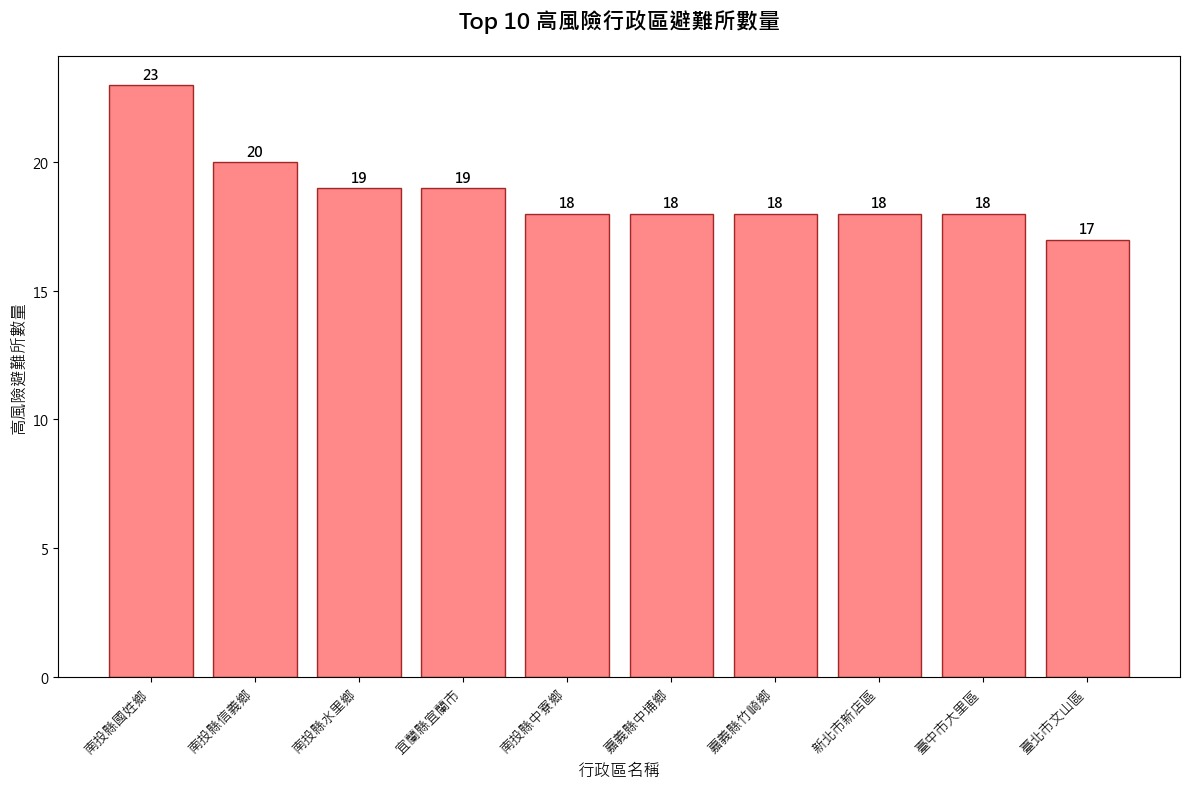

✅ 靜態長條圖已儲存至 outputs/risk_map.png

3. 產生互動式地圖...
轉換座標系統至 EPSG:4326...
✅ 互動式地圖已儲存至 outputs/interactive_risk_map.html
地圖中心點：[23.7848, 120.7074]
避難所標記數量：5907 個
避難所風險分佈：
  Safe: 3184 個
  High: 1052 個
  Low: 917 個
  Medium: 754 個

=== 輸出檔案清單 ===
✅ outputs/shelter_risk_audit.json (1,097,086 bytes)
✅ outputs/risk_map.png (184,454 bytes)
✅ outputs/interactive_risk_map.html (43,233,216 bytes)

🎉 Task D 完成！所有分析結果已匯出至 outputs/ 資料夾


In [22]:
# Task D: Visualization and Export
import json
import matplotlib.pyplot as plt
import folium
import os

# 確保必要的資料已載入
if 'shelters_with_township' not in locals():
    print("錯誤：請先執行 Task C 以生成分析資料")
else:
    print("開始執行視覺化與匯出...")
    
    # 1. 匯出 JSON 報表
    print("\n1. 匯出 JSON 報表...")
    
    try:
        # 挑選關鍵欄位
        export_columns = ['避難收容處所名稱', 'COUNTYNAME', 'TOWNNAME', 'risk_level', '預計收容人數']
        
        # 檢查欄位是否存在
        available_columns = [col for col in export_columns if col in shelters_with_township.columns]
        missing_columns = [col for col in export_columns if col not in shelters_with_township.columns]
        
        if missing_columns:
            print(f"警告：缺少欄位 {missing_columns}")
        
        # 準備匯出資料
        export_data = shelters_with_township[available_columns].copy()
        
        # 轉換為 JSON 格式
        json_output = export_data.to_json(
            orient='records',
            force_ascii=False,  # 支援中文
            indent=2
        )
        
        # 儲存至 outputs/shelter_risk_audit.json
        with open('outputs/shelter_risk_audit.json', 'w', encoding='utf-8') as f:
            f.write(json_output)
        
        print(f"✅ JSON 報表已匯出至 outputs/shelter_risk_audit.json")
        print(f"匯出記錄數：{len(export_data)} 筆")
        print(f"匯出欄位：{available_columns}")
        
    except Exception as e:
        print(f"❌ JSON 匯出失敗：{e}")
    
    # 2. 繪製靜態長條圖
    print("\n2. 繪製靜態長條圖...")
    
    try:
        # 設定中文字型
        plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
        plt.rcParams['axes.unicode_minus'] = False
        
        # 使用 Task C 的 top_10_df 資料
        if 'top_10_df' in locals():
            # 建立長條圖
            fig, ax = plt.subplots(figsize=(12, 8))
            
            # 繪製長條圖
            bars = ax.bar(
                range(len(top_10_df)), 
                top_10_df['高風險避難所數量'],
                color='#FF6B6B',
                alpha=0.8,
                edgecolor='darkred',
                linewidth=1
            )
            
            # 設定標題和標籤
            ax.set_title('Top 10 高風險行政區避難所數量', fontsize=16, fontweight='bold', pad=20)
            ax.set_xlabel('行政區名稱', fontsize=12)
            ax.set_ylabel('高風險避難所數量', fontsize=12)
            
            # 設定 X 軸標籤
            ax.set_xticks(range(len(top_10_df)))
            ax.set_xticklabels(top_10_df['行政區名稱'], rotation=45, ha='right')
            
            # 在長條圖上顯示數值
            for i, bar in enumerate(bars):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                       f'{int(height)}',
                       ha='center', va='bottom', fontweight='bold')
            
            # 調整版面
            plt.tight_layout()
            
            # 儲存圖片
            plt.savefig('outputs/risk_map.png', dpi=300, bbox_inches='tight', facecolor='white')
            plt.show()
            
            print("✅ 靜態長條圖已儲存至 outputs/risk_map.png")
            
        else:
            print("❌ 找不到 top_10_df 資料，請先執行 Task C")
            
    except Exception as e:
        print(f"❌ 長條圖繪製失敗：{e}")
    
    # 3. 產生互動式地圖
    print("\n3. 產生互動式地圖...")
    
    try:
        # 將所有資料轉換回 EPSG:4326 (WGS84)
        print("轉換座標系統至 EPSG:4326...")
        
        # 河川資料
        if rivers_gdf is not None:
            rivers_4326 = rivers_gdf.to_crs('EPSG:4326')
        else:
            rivers_4326 = None
            
        # 緩衝區資料（如果存在）
        if 'high_buffer' in locals():
            high_buffer_4326 = high_buffer.to_crs('EPSG:4326')
            med_buffer_4326 = med_buffer.to_crs('EPSG:4326')
            low_buffer_4326 = low_buffer.to_crs('EPSG:4326')
        else:
            high_buffer_4326 = med_buffer_4326 = low_buffer_4326 = None
            
        # 避難所資料
        shelters_4326 = shelters_with_township.to_crs('EPSG:4326')
        
        # 計算地圖中心點
        bounds = shelters_4326.total_bounds
        center_lat = (bounds[1] + bounds[3]) / 2
        center_lon = (bounds[0] + bounds[2]) / 2
        
        # 建立地圖
        m = folium.Map(
            location=[center_lat, center_lon],
            zoom_start=8,
            tiles='OpenStreetMap'
        )
        
        # 新增河川圖層（藍色）
        if rivers_4326 is not None:
            folium.GeoJson(
                rivers_4326,
                style_function=lambda x: {
                    'fillColor': '#3498db',
                    'color': '#2980b9',
                    'weight': 2,
                    'fillOpacity': 0.6
                },
                name='河川',
                tooltip='河川'
            ).add_to(m)
        
        # 新增緩衝區圖層
        if high_buffer_4326 is not None:
            # 高風險緩衝區（紅色）
            folium.GeoJson(
                high_buffer_4326,
                style_function=lambda x: {
                    'fillColor': '#e74c3c',
                    'color': '#c0392b',
                    'weight': 1,
                    'fillOpacity': 0.2
                },
                name='高風險緩衝區 (500m)',
                tooltip='高風險緩衝區 (500m)'
            ).add_to(m)
            
            # 中風險緩衝區（橙色）
            folium.GeoJson(
                med_buffer_4326,
                style_function=lambda x: {
                    'fillColor': '#f39c12',
                    'color': '#d68910',
                    'weight': 1,
                    'fillOpacity': 0.15
                },
                name='中風險緩衝區 (1km)',
                tooltip='中風險緩衝區 (1km)'
            ).add_to(m)
            
            # 低風險緩衝區（黃色）
            folium.GeoJson(
                low_buffer_4326,
                style_function=lambda x: {
                    'fillColor': '#f1c40f',
                    'color': '#d4ac0d',
                    'weight': 1,
                    'fillOpacity': 0.1
                },
                name='低風險緩衝區 (2km)',
                tooltip='低風險緩衝區 (2km)'
            ).add_to(m)
        
        # 定義風險等級顏色
        risk_colors = {
            'High': '#e74c3c',    # 紅色
            'Medium': '#f39c12',  # 橙色
            'Low': '#f1c40f',     # 黃色
            'Safe': '#27ae60'     # 綠色
        }
        
        # 新增避難所點位
        for idx, shelter in shelters_4326.iterrows():
            # 取得座標
            lon, lat = shelter.geometry.x, shelter.geometry.y
            
            # 取得避難所資訊
            name = shelter.get('避難收容處所名稱', '未知避難所')
            capacity = shelter.get('預計收容人數', 0)
            risk_level = shelter.get('risk_level', 'Unknown')
            county = shelter.get('COUNTYNAME', '未知')
            town = shelter.get('TOWNNAME', '未知')
            
            # 建立彈出視窗內容
            popup_content = f"""
            <b>{name}</b><br>
            風險等級：{risk_level}<br>
            預計收容人數：{capacity} 人<br>
            位置：{county}{town}
            """
            
            # 新增標記
            folium.CircleMarker(
                location=[lat, lon],
                radius=6,
                popup=folium.Popup(popup_content, max_width=200),
                tooltip=f"{name} ({risk_level})",
                color=risk_colors.get(risk_level, '#95a5a6'),
                fillColor=risk_colors.get(risk_level, '#95a5a6'),
                fillOpacity=0.8,
                weight=2
            ).add_to(m)
        
        # 新增圖層控制
        folium.LayerControl().add_to(m)
        
        # 新增圖例
        legend_html = '''
        <div style="position: fixed; 
                    bottom: 50px; left: 50px; width: 150px; height: 120px; 
                    background-color: white; border:2px solid grey; z-index:9999; 
                    font-size:14px; padding: 10px">
        <h4>風險等級圖例</h4>
        <i class="fa fa-circle" style="color:#e74c3c"></i> 高風險 (High)<br>
        <i class="fa fa-circle" style="color:#f39c12"></i> 中風險 (Medium)<br>
        <i class="fa fa-circle" style="color:#f1c40f"></i> 低風險 (Low)<br>
        <i class="fa fa-circle" style="color:#27ae60"></i> 安全 (Safe)
        </div>
        '''
        m.get_root().html.add_child(folium.Element(legend_html))
        
        # 儲存地圖
        m.save('outputs/interactive_risk_map.html')
        
        print("✅ 互動式地圖已儲存至 outputs/interactive_risk_map.html")
        print(f"地圖中心點：[{center_lat:.4f}, {center_lon:.4f}]")
        print(f"避難所標記數量：{len(shelters_4326)} 個")
        
        # 顯示地圖統計
        risk_counts = shelters_4326['risk_level'].value_counts()
        print(f"避難所風險分佈：")
        for risk, count in risk_counts.items():
            color = risk_colors.get(risk, '#95a5a6')
            print(f"  {risk}: {count} 個")
        
    except Exception as e:
        print(f"❌ 互動式地圖產生失敗：{e}")
    
    # 4. 輸出檔案清單
    print(f"\n=== 輸出檔案清單 ===")
    output_files = [
        'outputs/shelter_risk_audit.json',
        'outputs/risk_map.png',
        'outputs/interactive_risk_map.html'
    ]
    
    for file_path in output_files:
        if os.path.exists(file_path):
            file_size = os.path.getsize(file_path)
            print(f"✅ {file_path} ({file_size:,} bytes)")
        else:
            print(f"❌ {file_path} (檔案不存在)")
    
    print(f"\n🎉 Task D 完成！所有分析結果已匯出至 outputs/ 資料夾")